In [1]:
import pandas as pd
import numpy as np

data = {
    "Month": [
        "2024-01-01", "2024-02-01", "2024-03-01", "2024-04-01",
        "2024-05-01", "2024-06-01", "2024-07-01", "2024-08-01",
        "2024-09-01", "2024-10-01", "2024-11-01", "2024-12-01",
        "2025-01-01", "2025-02-01", "2025-03-01", "2025-04-01",
        "2025-05-01", "2025-06-01", "2025-07-01", "2025-08-01",
        "2025-09-01", "2025-10-01", "2025-11-01", "2025-12-01"
    ],
    "Demand": [
        116459, 110959, 125796, 122998, 134730, 128671,
        125833, 130514, 128302, 147466, 154088, 146239,
        121984, 112460, 130621, 129137, 142971, 133178,
        132764, 137276, 133856, 155125, 159567, 152123
    ],
    "Capacity": [
        151552, 142099, 151669, 146085, 151147, 146704,
        151223, 152191, 146221, 151543, 147194, 151309,
        151563, 137469, 151134, 147182, 151569, 146869,
        151290, 151406, 145718, 151477, 146653, 151631
    ]
}

df = pd.DataFrame(data)

df["Month"] = pd.to_datetime(df["Month"])

df.head()

,Month,Demand,Capacity
0,2024-01-01,116459,151552
1,2024-02-01,110959,142099
2,2024-03-01,125796,151669
3,2024-04-01,122998,146085
4,2024-05-01,134730,151147


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Month     24 non-null     datetime64[us]
 1   Demand    24 non-null     int64         
 2   Capacity  24 non-null     int64         
dtypes: datetime64[us](1), int64(2)
memory usage: 708.0 bytes


In [3]:
df.isnull().sum()

Month       0
Demand      0
Capacity    0
dtype: int64

In [5]:
#3-Month Moving Average

In [4]:
df["3M_Moving_Average"] = df["Demand"].rolling(window=3).mean()

df

,Month,Demand,Capacity,3M_Moving_Average
0,2024-01-01,116459,151552,NaN
1,2024-02-01,110959,142099,NaN
2,2024-03-01,125796,151669,117738.000000
3,2024-04-01,122998,146085,119917.666667
4,2024-05-01,134730,151147,127841.333333
5,2024-06-01,128671,146704,128799.666667
6,2024-07-01,125833,151223,129744.666667
7,2024-08-01,130514,152191,128339.333333
8,2024-09-01,128302,146221,128216.333333
9,2024-10-01,147466,151543,135427.333333


In [6]:
#Exponential Smoothing

In [7]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

model = ExponentialSmoothing(
    df["Demand"],
    trend="add",
    seasonal=None
)

fit = model.fit()

df["Exponential_Smoothing"] = fit.fittedvalues

df

,Month,Demand,Capacity,3M_Moving_Average,Exponential_Smoothing
0,2024-01-01,116459,151552,NaN,114640.967743
1,2024-02-01,110959,142099,NaN,117830.786621
2,2024-03-01,125796,151669,117738.000000,113823.591993
3,2024-04-01,122998,146085,119917.666667,125423.388160
4,2024-05-01,134730,151147,127841.333333,125098.754725
5,2024-06-01,128671,146704,128799.666667,134759.571492
6,2024-07-01,125833,151223,129744.666667,131401.045143
7,2024-08-01,130514,152191,128339.333333,128473.625037
8,2024-09-01,128302,146221,128216.333333,131847.590843
9,2024-10-01,147466,151543,135427.333333,130595.191945


In [8]:
#One important observation: it reacts more quickly to recent demand changes than the 3-month moving average. For example, by December 2025:

#Moving Average: 155,605
#Exponential Smoothing: 160,223
#Actual December demand: 152,123

In [9]:
#Compare forecasting accuracy

#We'll calculate MAE (Mean Absolute Error)

In [10]:
from sklearn.metrics import mean_absolute_error

mae_moving_average = mean_absolute_error(
    df["Demand"].iloc[2:],
    df["3M_Moving_Average"].iloc[2:]
)

mae_exponential_smoothing = mean_absolute_error(
    df["Demand"],
    df["Exponential_Smoothing"]
)

print("3-Month Moving Average MAE:", round(mae_moving_average, 2))
print("Exponential Smoothing MAE:", round(mae_exponential_smoothing, 2))

3-Month Moving Average MAE: 6446.18
Exponential Smoothing MAE: 8565.49


In [12]:
#The 3-Month Moving Average has about 24.7% lower MAE than Exponential Smoothing

In [13]:
#Forecast the next 6 months

In [14]:
forecast_df = df[["Month", "Demand", "Capacity"]].copy()

future_months = pd.date_range(
    start="2026-01-01",
    periods=6,
    freq="MS"
)

forecast_values = []

history = df["Demand"].tolist()

for month in future_months:
    forecast = np.mean(history[-3:])
    forecast_values.append(round(forecast, 2))
    history.append(forecast)

future_df = pd.DataFrame({
    "Month": future_months,
    "Forecast_Demand": forecast_values
})

future_df

,Month,Forecast_Demand
0,2026-01-01,155605.00
1,2026-02-01,155765.00
2,2026-03-01,154497.67
3,2026-04-01,155289.22
4,2026-05-01,155183.96
5,2026-06-01,154990.28


In [15]:
#We have a clear result:

#3-Month Moving Average MAE: 6,446
#Exponential Smoothing MAE: 8,565
#Moving Average is approximately 24.7% more accurate based on MAE.

In [16]:
#Add the forecast to capacity planning

In [17]:
recent_capacity = df["Capacity"].tail(3).mean()

future_df["Planning_Capacity"] = round(recent_capacity, 2)

future_df["Capacity_Gap"] = (
    future_df["Forecast_Demand"] - future_df["Planning_Capacity"]
)

future_df["Utilisation_Rate"] = round(
    future_df["Forecast_Demand"]
    / future_df["Planning_Capacity"] * 100,
    2
)

future_df

,Month,Forecast_Demand,Planning_Capacity,Capacity_Gap,Utilisation_Rate
0,2026-01-01,155605.00,149920.33,5684.67,103.79
1,2026-02-01,155765.00,149920.33,5844.67,103.90
2,2026-03-01,154497.67,149920.33,4577.34,103.05
3,2026-04-01,155289.22,149920.33,5368.89,103.58
4,2026-05-01,155183.96,149920.33,5263.63,103.51
5,2026-06-01,154990.28,149920.33,5069.95,103.38


In [18]:
#Forecast interpretation

#All six projected months are above the planning capacity baseline:

#Average forecast demand: ~155,222
#Planning capacity: ~149,920
#Average capacity gap: ~5,301 units
#Utilisation: roughly 103–104% every month

In [19]:
#existing capacity would not comfortably support expected demand in the first half of 2026.

In [20]:
#Create a simple risk flag

In [21]:
future_df["Risk_Level"] = np.where(
    future_df["Forecast_Demand"] > future_df["Planning_Capacity"],
    "Critical",
    "Within Capacity"
)

future_df

,Month,Forecast_Demand,Planning_Capacity,Capacity_Gap,Utilisation_Rate,Risk_Level
0,2026-01-01,155605.00,149920.33,5684.67,103.79,Critical
1,2026-02-01,155765.00,149920.33,5844.67,103.90,Critical
2,2026-03-01,154497.67,149920.33,4577.34,103.05,Critical
3,2026-04-01,155289.22,149920.33,5368.89,103.58,Critical
4,2026-05-01,155183.96,149920.33,5263.63,103.51,Critical
5,2026-06-01,154990.28,149920.33,5069.95,103.38,Critical


In [22]:
#all six projected months are Critical, 
#with forecast demand exceeding planning capacity by roughly 4,577–5,845 units/month.

In [23]:
future_df["Forecast_Method"] = "3-Month Moving Average"

future_df["Required_Additional_Capacity"] = np.maximum(
    future_df["Capacity_Gap"], 0
)

future_df

,Month,Forecast_Demand,Planning_Capacity,Capacity_Gap,Utilisation_Rate,Risk_Level,Forecast_Method,Required_Additional_Capacity
0,2026-01-01,155605.00,149920.33,5684.67,103.79,Critical,3-Month Moving Average,5684.67
1,2026-02-01,155765.00,149920.33,5844.67,103.90,Critical,3-Month Moving Average,5844.67
2,2026-03-01,154497.67,149920.33,4577.34,103.05,Critical,3-Month Moving Average,4577.34
3,2026-04-01,155289.22,149920.33,5368.89,103.58,Critical,3-Month Moving Average,5368.89
4,2026-05-01,155183.96,149920.33,5263.63,103.51,Critical,3-Month Moving Average,5263.63
5,2026-06-01,154990.28,149920.33,5069.95,103.38,Critical,3-Month Moving Average,5069.95


In [24]:
final_forecast = future_df.copy()

final_forecast.to_csv(
    "Nexora Forecast 2026.csv",
    index=False
)

final_forecast

,Month,Forecast_Demand,Planning_Capacity,Capacity_Gap,Utilisation_Rate,Risk_Level,Forecast_Method,Required_Additional_Capacity
0,2026-01-01,155605.00,149920.33,5684.67,103.79,Critical,3-Month Moving Average,5684.67
1,2026-02-01,155765.00,149920.33,5844.67,103.90,Critical,3-Month Moving Average,5844.67
2,2026-03-01,154497.67,149920.33,4577.34,103.05,Critical,3-Month Moving Average,4577.34
3,2026-04-01,155289.22,149920.33,5368.89,103.58,Critical,3-Month Moving Average,5368.89
4,2026-05-01,155183.96,149920.33,5263.63,103.51,Critical,3-Month Moving Average,5263.63
5,2026-06-01,154990.28,149920.33,5069.95,103.38,Critical,3-Month Moving Average,5069.95


In [25]:
forecast_summary = {
    "Average Forecast Demand": round(future_df["Forecast_Demand"].mean(), 2),
    "Planning Capacity": round(future_df["Planning_Capacity"].mean(), 2),
    "Average Capacity Gap": round(future_df["Capacity_Gap"].mean(), 2),
    "Average Utilisation Rate": round(future_df["Utilisation_Rate"].mean(), 2),
    "Total Additional Capacity Required": round(
        future_df["Required_Additional_Capacity"].sum(), 2
    )
}

forecast_summary

{'Average Forecast Demand': np.float64(155221.86),
 'Planning Capacity': np.float64(149920.33),
 'Average Capacity Gap': np.float64(5301.53),
 'Average Utilisation Rate': np.float64(103.54),
 'Total Additional Capacity Required': np.float64(31809.15)}

In [26]:
#These are the final forecast-level numbers we need:

#Average forecast demand: 155,221.86
#Planning capacity: 149,920.33
#Average monthly gap: 5,301.53
#Average utilisation: 103.54%
#Total additional capacity required for Jan–Jun 2026: 31,809.15 units
#All six months are Critical

In [27]:
#Forecast visualization

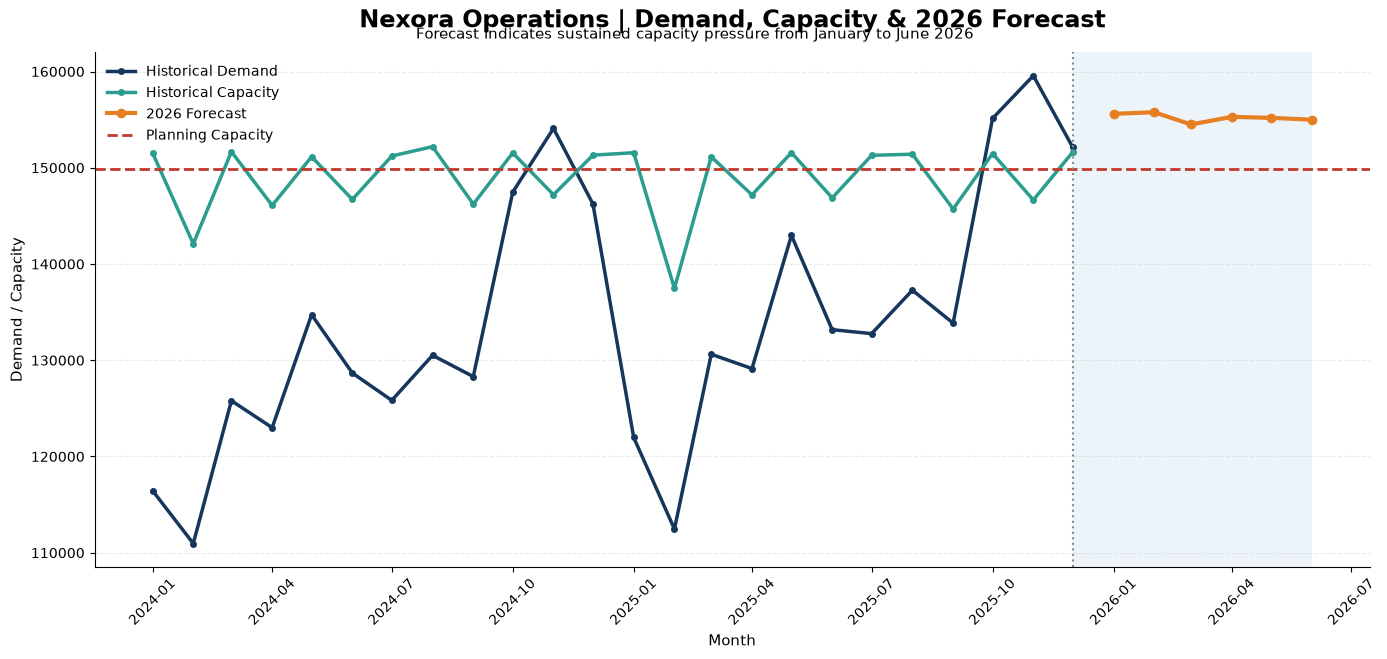

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

# Historical demand
plt.plot(
    df["Month"],
    df["Demand"],
    color="#17365D",
    linewidth=2.5,
    marker="o",
    markersize=4,
    label="Historical Demand"
)

# Historical capacity
plt.plot(
    df["Month"],
    df["Capacity"],
    color="#2A9D8F",
    linewidth=2.5,
    marker="o",
    markersize=4,
    label="Historical Capacity"
)

# Forecast demand
plt.plot(
    future_df["Month"],
    future_df["Forecast_Demand"],
    color="#E67E22",
    linewidth=3,
    marker="o",
    markersize=6,
    label="2026 Forecast"
)

# Planning capacity
plt.axhline(
    y=recent_capacity,
    color="#C0392B",
    linestyle="--",
    linewidth=2,
    label="Planning Capacity"
)

# Separate historical and forecast periods
plt.axvline(
    x=df["Month"].iloc[-1],
    color="#7F8C8D",
    linestyle=":",
    linewidth=1.5
)

# Forecast shading
plt.axvspan(
    df["Month"].iloc[-1],
    future_df["Month"].iloc[-1],
    alpha=0.08
)

# Titles
plt.title(
    "Nexora Operations | Demand, Capacity & 2026 Forecast",
    fontsize=17,
    fontweight="bold",
    pad=18
)

plt.suptitle(
    "Forecast indicates sustained capacity pressure from January to June 2026",
    fontsize=11,
    y=0.91
)

plt.xlabel("Month", fontsize=11)
plt.ylabel("Demand / Capacity", fontsize=11)

# Grid
plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

# Legend
plt.legend(
    loc="upper left",
    frameon=False,
    fontsize=10
)

# Clean borders
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()